# PINNs: ODE capacitor charge

$$
\begin{cases}
    \dot{v} + \frac{1}{RC}v - \frac{V}{RC} = 0 \\
    \\
    v(0) = 0
    \\
\end{cases}
$$

Solution: 
$$
    v(t) = V\left(1-e^{\frac{-t}{RC}}\right)
$$

In [1]:
# imports
# torch
import torch
import torch.nn as nn
import torch.optim as optim

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

In [2]:
# Define the PINN model
class PINN(nn.Module):

    
    def __init__(self):
        # define arbitrary network
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),   # Input layer with 1 feature (domain is one dimensional)
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1)    # Output layer for u(x), again, one dimensional.
        )

        # init equation parameters
        self.R = 1
        self.C = 1
        self.V = 5

    # simple forward method
    def forward(self, x):
        return self.net(x)
    
    # Define the Poisson equation loss function
    def capacitor_charge_loss(self, t):

        # alias to simplify notation
        R = self.R
        C = self.C
        V = self.V

        # estimate output voltage
        v = self.forward(t) # v = model(t)

        # get derivative of first order
        dv = torch.autograd.grad(v, t, grad_outputs=torch.ones_like(v), create_graph=True)[0]

        # diff equation residue function
        f = (dv + v/(R*C) - V/(R*C))**2

        return torch.mean(f)
    
    def boundary_condition_loss(self, t0, v0):

        # estimation for v0
        v0_est = self.forward(t0)

        # residue for v0
        residue_v0 = (v0_est - v0)**2

        return torch.mean(residue_v0)

In [3]:
# Training data
# domain distributed data
t = 10*torch.rand(100, 1)  # Randomly sampled points in [0, 1]
t.requires_grad = True

# initial conditions data
t0 = torch.tensor([0.0], requires_grad=True)
v0 = torch.tensor([0.0], requires_grad=True)

# Create PINN model
model = PINN()

optimizer = optim.Adam(params=model.parameters(), lr=0.001)

# Training loop
epochs = 10000
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Compute the loss
    # TODO: Notice, no labeled data was used here
    loss = model.capacitor_charge_loss(t) + model.boundary_condition_loss(t0, v0)
    
    # Backpropagation
    loss.backward()
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item()}")

Epoch [0/10000], Loss: 23.648038864135742
Epoch [1000/10000], Loss: 0.0002279193577123806
Epoch [2000/10000], Loss: 3.290522363386117e-05
Epoch [3000/10000], Loss: 2.6361381969763897e-05
Epoch [4000/10000], Loss: 2.1147825464140624e-05
Epoch [5000/10000], Loss: 1.5221194189507514e-05
Epoch [6000/10000], Loss: 9.058298928721342e-06
Epoch [7000/10000], Loss: 3.5291416224936256e-06
Epoch [8000/10000], Loss: 6.094659852351469e-07
Epoch [9000/10000], Loss: 1.0240348302659186e-07


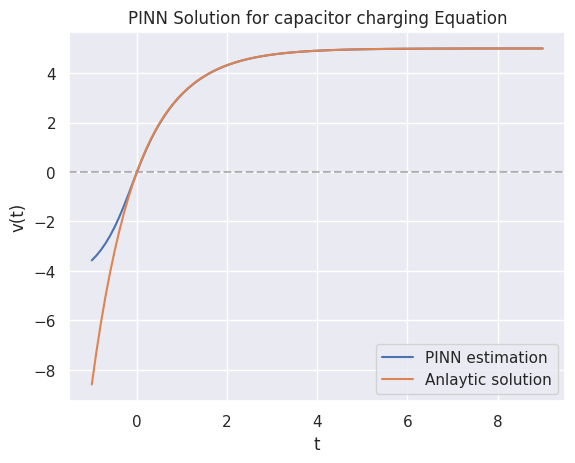

In [4]:
# alias to simplify notation
R = model.R
C = model.C
V = model.V

# Test the model
t_test = 10*(torch.linspace(0, 1, 100).reshape(-1, 1)-.1)
v_test = model(t_test)
v_real = model.V*(1-torch.exp(-t_test/(R*C)))

# Plot the results
import matplotlib.pyplot as plt
plt.axhline(y = 0, color = 'k', linestyle = '--', alpha=0.3) 
plt.plot(t_test.detach().numpy(), v_test.detach().numpy(), label="PINN estimation")
plt.plot(t_test.detach().numpy(), v_real.detach().numpy(), label="Anlaytic solution")
plt.xlabel('t')
plt.ylabel('v(t)')
plt.title('PINN Solution for capacitor charging Equation')
plt.legend()
plt.show()